In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os
import IPython.display as ipd
#from PIL import Image


Ques 1 a)

In [3]:
import time
def random_number_generator(size):
    seed = int(time.time() * 1000)
    a = 1103515245
    c = 12345
    m = 2**31

    random_numbers = []
    for _ in range(size):
        seed = (a * seed + c) % m
        random_numbers.append(seed / m)

    return random_numbers


50


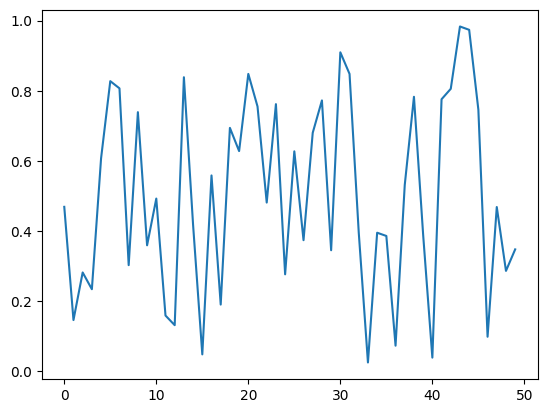

In [4]:
#plotting 1*N
n = int(input())
num = random_number_generator(n)
plt.plot(num)
plt.show()

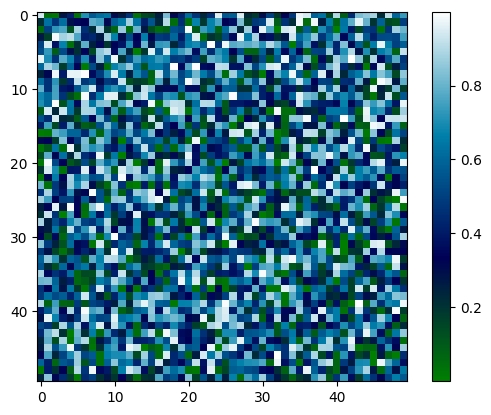

In [5]:
#plotting N*N
random_NxN_array = np.array(random_number_generator(n * n)).reshape(n,n)
plt.imshow(random_NxN_array,cmap='ocean')
plt.colorbar()
plt.show()

Mounting Drive

In [6]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [8]:
os.chdir("/content/drive/MyDrive/Colab Notebooks/Dataset/MLA1")

In [ ]:
#extracting tar.xz file
#!tar -xf MLA1_DATA.tar.xz

In [9]:
#exploring dataset
f_path= '/content/drive/MyDrive/Colab Notebooks/Dataset/MLA1/MLA1_DATA'
all_folders = os.listdir(f_path)
all_folders

['metadata.txt', 'ImageAudio', 'CSV']

**Ques** 2 Using above implemented random number generator select 12 samples from the EEG data
and print there metadata.

In [10]:
#writing function to fetch csv files using random indexes
def get_csv(csv_folder_path, indexes):
    all_files = os.listdir(folder_path)
    csv_files = []
    for file in all_files:
      if file.endswith('.csv'):
        csv_files.append(file)
    print(len(csv_files))
    selected_files = []
    for i in indexes:
      file_name = csv_files[i]
      selected_files.append(file_name)
    return selected_files



In [11]:
ind = random_number_generator(12)
indexes =[]
for i in ind:
  indexes.append(int(i*10032))
indexes

[3323, 9224, 2449, 3004, 8116, 14, 6496, 5628, 2188, 5229, 7602, 7541]

In [12]:
folder_path = "/content/drive/MyDrive/Colab Notebooks/Dataset/MLA1/MLA1_DATA/CSV"
selected_csv_filenames = get_csv(folder_path, indexes)
print("Size of selected_csv_filenames " ,len(selected_csv_filenames))
selected_csv_filenames


10032
Size of selected_csv_filenames  12


['MindBigData_Imagenet_Insight_n02493509_6224_1_1271.csv',
 'MindBigData_Imagenet_Insight_n02687172_12096_1_155.csv',
 'MindBigData_Imagenet_Insight_n02118333_14509_1_1506.csv',
 'MindBigData_Imagenet_Insight_n04004767_4348_1_1220.csv',
 'MindBigData_Imagenet_Insight_n04074963_26855_1_336.csv',
 'MindBigData_Imagenet_Insight_n06892775_13332_1_1819.csv',
 'MindBigData_Imagenet_Insight_n03745146_28820_1_709.csv',
 'MindBigData_Imagenet_Insight_n03790512_9380_1_940.csv',
 'MindBigData_Imagenet_Insight_n03538406_7539_1_1452.csv',
 'MindBigData_Imagenet_Insight_n02879718_18086_1_848.csv',
 'MindBigData_Imagenet_Insight_n03372029_63603_1_519.csv',
 'MindBigData_Imagenet_Insight_n02111129_2949_1_525.csv']

In [13]:
name_list = []
for filename in selected_csv_filenames:
    parts = filename.split('_')[3]
    name_list.append(parts)
print("Size ",len(name_list))
print(name_list)

Size  12
['n02493509', 'n02687172', 'n02118333', 'n04004767', 'n04074963', 'n06892775', 'n03745146', 'n03790512', 'n03538406', 'n02879718', 'n03372029', 'n02111129']


In [14]:
#creating dataframe of metadata.txt and making 3 list of comma seperated string, number and name code
meta_path = '/content/drive/MyDrive/Colab Notebooks/Dataset/MLA1/MLA1_DATA/metadata.txt'
string_data = []
numbers = []
name_code = []

with open(meta_path, 'r') as file:
    for line in file:
        parts = line.strip().rsplit('\t', 2)
        if len(parts) == 3:
            description, number, code = parts
            string_data.append(description)
            numbers.append(int(number))
            name_code.append(code)

meta_df = pd.DataFrame({
    'string': string_data,
    'Number': numbers,
    'Code': name_code
})

print(len(name_code))  # Prints the number of unique name codes present in metadata.txt


569


In [15]:
meta_df.head()

,string,Number,Code
0,"domestic cat, house cat, Felis domesticus, Fel...",16,n02121808
1,"rock python, rock snake, Python sebae",24,n01744401
2,magpie,22,n01582220
3,Chihuahua,22,n02085620
4,"flute, transverse flute",18,n03372029


In [16]:
meta_df['Code'].nunique()

569

In [17]:
meta_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   string  569 non-null    object
 1   Number  569 non-null    int64 
 2   Code    569 non-null    object
dtypes: int64(1), object(2)
memory usage: 13.5+ KB


In [18]:
name_list

['n02493509',
 'n02687172',
 'n02118333',
 'n04004767',
 'n04074963',
 'n06892775',
 'n03745146',
 'n03790512',
 'n03538406',
 'n02879718',
 'n03372029',
 'n02111129']

Printing Metadata of 12 samples

In [19]:
for i in name_list:
  filtered_df = meta_df[meta_df['Code'] == i]
  print(filtered_df)

               string  Number       Code
56  titi, titi monkey      20  n02493509
                                                string  Number       Code
270  aircraft carrier, carrier, flattop, attack air...       6  n02687172
   string  Number       Code
48    fox      20  n02118333
      string  Number       Code
279  printer      21  n04004767
                     string  Number       Code
110  remote control, remote      20  n04074963
      string  Number       Code
427  concert      18  n06892775
                               string  Number       Code
99  menagerie, zoo, zoological garden      22  n03745146
               string  Number       Code
168  motorcycle, bike      18  n03790512
                     string  Number       Code
502  horse cart, horse-cart      20  n03538406
    string  Number       Code
522    bow      28  n02879718
                    string  Number       Code
4  flute, transverse flute      18  n03372029
       string  Number       Code
456  Leonberg  

**Ques** 3 Implement a normalization function which can normalize given data in range [-x, x ].
Normalize and plot 4 randomly selected EEG signals.

In [20]:
def norm_func(arr,x):
    li=[]
    mini = min(arr)
    maxi = max(arr)
    a = (mini+maxi)/2;
    b = (a-mini)/x;
    for i in arr:
      k = (i-a)/b
      li.append(round(k,3))
    return li

In [21]:
num = random_number_generator(4)
li =[]
for i in num:
  li.append(int(i*10032))
li

[8855, 3992, 4204, 8385]

In [23]:
f_path= '/content/drive/MyDrive/Colab Notebooks/Dataset/MLA1/MLA1_DATA/CSV'
all_folders = os.listdir(f_path)
sample_csv =[]
for i in li:
  sample_csv.append(all_folders[i])
sample_csv



['MindBigData_Imagenet_Insight_n02107312_3248_1_277.csv',
 'MindBigData_Imagenet_Insight_n02100735_4949_1_1411.csv',
 'MindBigData_Imagenet_Insight_n01582220_80_1_1061.csv',
 'MindBigData_Imagenet_Insight_n10565667_8400_1_378.csv']

In [24]:
f_path= '/content/drive/MyDrive/Colab Notebooks/Dataset/MLA1/MLA1_DATA/CSV/MindBigData_Imagenet_Insight_n04336792_13277_1_1319.csv'
df = pd.read_csv(f_path,header=None,index_col=0).T
df.head()

,AF3,AF4,T7,T8,Pz
1,4260.000000,4208.717949,4228.717949,4213.846154,4147.179487
2,4276.923077,4222.051282,4225.128205,4219.487179,4151.794872
3,4295.897436,4241.538462,4227.179487,4216.923077,4154.358974
4,4286.153846,4230.769231,4234.358974,4225.128205,4154.871795
5,4278.974359,4224.615385,4235.897436,4230.256410,4149.743590


Normalizing csv files and their respective plot



Normalised value of  MindBigData_Imagenet_Insight_n02107312_3248_1_277.csv
0    AF3    AF4     T7     T8     Pz
1 -1.106 -0.582 -0.713  0.419  0.623
2 -1.106 -0.921 -1.172  0.581  0.164
3 -0.981 -0.921 -0.897  0.419  0.000
4 -0.907 -0.646  0.253  0.349  0.164
5 -0.758 -0.519  0.391  0.395  0.426


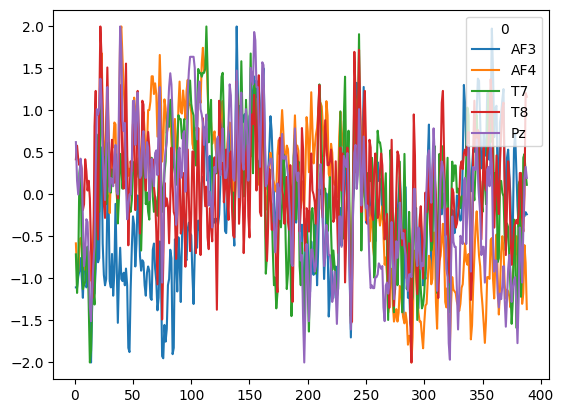

Normalised value of  MindBigData_Imagenet_Insight_n02100735_4949_1_1411.csv
0    AF3    AF4     T7     T8     Pz
1  1.271  1.176 -1.093 -0.561  0.644
2  1.521  1.227 -1.733  0.119  0.734
3  1.437  2.000 -0.053  1.352  0.508
4  0.937  1.782  0.320  1.162  0.734
5  0.333  0.739 -1.467  0.403  0.983


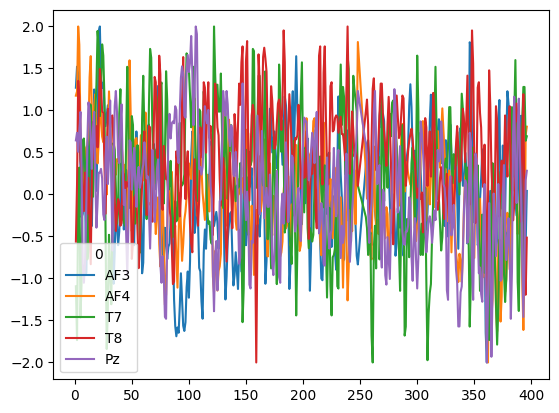

Normalised value of  MindBigData_Imagenet_Insight_n01582220_80_1_1061.csv
0    AF3    AF4     T7     T8     Pz
1 -1.372 -0.498  0.085  0.653 -0.355
2  0.163  0.288  0.598  1.598  0.383
3  0.186 -0.410 -0.222 -0.030  0.099
4 -0.907 -0.917 -1.111 -1.457 -0.383
5 -0.953 -0.568 -1.179 -0.111 -0.355


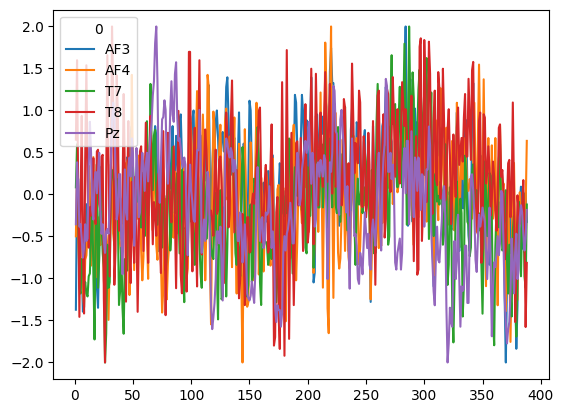

Normalised value of  MindBigData_Imagenet_Insight_n10565667_8400_1_378.csv
0    AF3   AF4     T7     T8     Pz
1  0.742 -0.56 -0.940  0.404 -0.638
2  0.584  0.06 -2.000  0.038 -0.922
3  0.404  0.40 -1.556  0.154 -1.348
4  0.966  0.20 -0.325  0.596 -1.518
5  1.101 -0.22 -0.154  0.212 -0.837


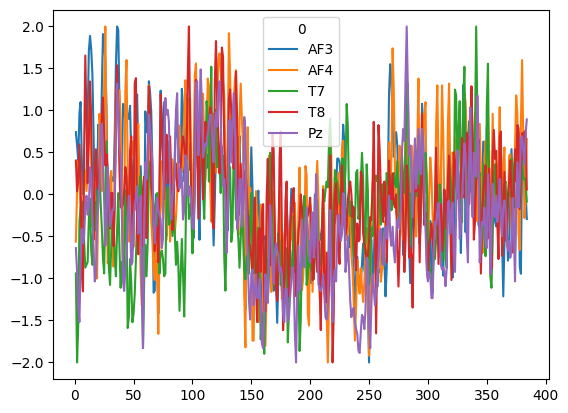

<Figure size 640x480 with 0 Axes>

In [25]:
for i in sample_csv:
  f_path= '/content/drive/MyDrive/Colab Notebooks/Dataset/MLA1/MLA1_DATA/CSV/'+i
  df = pd.read_csv(f_path,header=None,index_col=0).T
  x = 2
  df_normalized = df.apply(lambda col: norm_func(col, x))
  print("Normalised value of ",i)
  print(df_normalized.head())
  df_normalized.plot()
  plt.show()

plt.tight_layout()





Ques 4 a)Reshape image to (3,224,224)

In [26]:
#selected sample from previous questions
sample_csv

['MindBigData_Imagenet_Insight_n02107312_3248_1_277.csv',
 'MindBigData_Imagenet_Insight_n02100735_4949_1_1411.csv',
 'MindBigData_Imagenet_Insight_n01582220_80_1_1061.csv',
 'MindBigData_Imagenet_Insight_n10565667_8400_1_378.csv']

In [27]:
#fetch the no code from above selected files
name_codes = []
for i in sample_csv:
    parts = i.split('_')[3]
    name_codes.append(parts)

print(name_codes)

['n02107312', 'n02100735', 'n01582220', 'n10565667']


In [31]:
#creating list of all the paths of above selected EEG data
folder_paths = []
i_path= '/content/drive/MyDrive/Colab Notebooks/Dataset/MLA1/MLA1_DATA/ImageAudio/'
for i in name_codes:
    full_path = i_path + i
    folder_paths.append(full_path)
folder_paths

['/content/drive/MyDrive/Colab Notebooks/Dataset/MLA1/MLA1_DATA/ImageAudio/n02107312',
 '/content/drive/MyDrive/Colab Notebooks/Dataset/MLA1/MLA1_DATA/ImageAudio/n02100735',
 '/content/drive/MyDrive/Colab Notebooks/Dataset/MLA1/MLA1_DATA/ImageAudio/n01582220',
 '/content/drive/MyDrive/Colab Notebooks/Dataset/MLA1/MLA1_DATA/ImageAudio/n10565667']

In [32]:
#selecting all images in single list to reshape
image_paths=[]
for path in folder_paths:
  all_files = os.listdir(path)
  c=0
  for i in all_files:
    if c==4:
      break
    else:
      image_paths.append(path+'/'+i)
      c+=1
print(len(image_paths))
image_paths

#here i have selected 4 images from each folder and store these paths in a single folder

16


['/content/drive/MyDrive/Colab Notebooks/Dataset/MLA1/MLA1_DATA/ImageAudio/n02107312/n02107312_5387.JPEG',
 '/content/drive/MyDrive/Colab Notebooks/Dataset/MLA1/MLA1_DATA/ImageAudio/n02107312/n02107312_6495.JPEG',
 '/content/drive/MyDrive/Colab Notebooks/Dataset/MLA1/MLA1_DATA/ImageAudio/n02107312/n02107312_4799.JPEG',
 '/content/drive/MyDrive/Colab Notebooks/Dataset/MLA1/MLA1_DATA/ImageAudio/n02107312/n02107312_7504.JPEG',
 '/content/drive/MyDrive/Colab Notebooks/Dataset/MLA1/MLA1_DATA/ImageAudio/n02100735/n02100735_6388.JPEG',
 '/content/drive/MyDrive/Colab Notebooks/Dataset/MLA1/MLA1_DATA/ImageAudio/n02100735/n02100735_6583.JPEG',
 '/content/drive/MyDrive/Colab Notebooks/Dataset/MLA1/MLA1_DATA/ImageAudio/n02100735/n02100735_998.JPEG',
 '/content/drive/MyDrive/Colab Notebooks/Dataset/MLA1/MLA1_DATA/ImageAudio/n02100735/n02100735_4527.JPEG',
 '/content/drive/MyDrive/Colab Notebooks/Dataset/MLA1/MLA1_DATA/ImageAudio/n01582220/n01582220_5136.JPEG',
 '/content/drive/MyDrive/Colab Noteboo

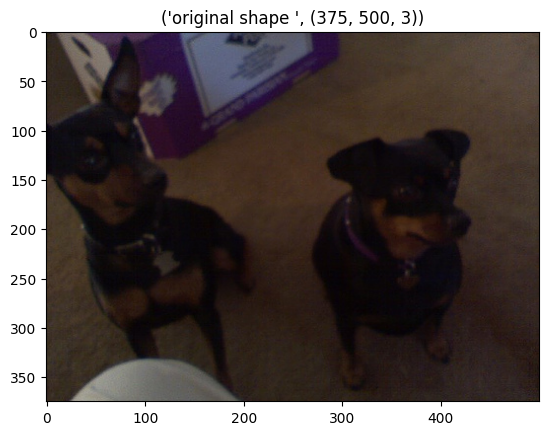

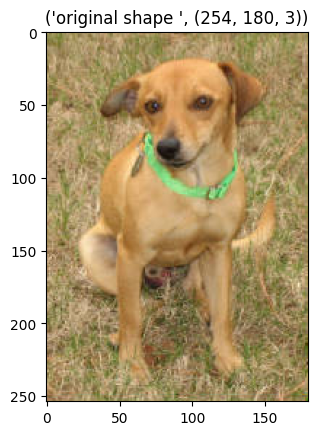

In [33]:
from PIL import Image
import matplotlib.pyplot as plt
c=0
for i in image_paths:
  image = Image.open(i)
  image_array = np.array(image)
  plt.title(("original shape " ,image_array.shape))
  plt.imshow(image_array)
  plt.show()
  if c==10:
    break
  c=10


In [34]:
def reshape_image(image_path, target_size=(224, 224)):
    image = Image.open(image_path)
    image = image.resize(target_size)
    image_array = np.array(image)
    image_array = np.transpose(image_array, (2, 0, 1))
    return image_array


In [35]:
reshaped_images = []
for image_path in image_paths:
    reshaped_image = reshape_image(image_path, target_size=(224, 224))
    reshaped_images.append(reshaped_image)


Printing shapes reshaped images

In [36]:
for i in range(len(reshaped_images)):
  print(reshaped_images[i].shape)

(3, 224, 224)
(3, 224, 224)
(3, 224, 224)
(3, 224, 224)
(3, 224, 224)
(3, 224, 224)
(3, 224, 224)
(3, 224, 224)
(3, 224, 224)
(3, 224, 224)
(3, 224, 224)
(3, 224, 224)
(3, 224, 224)
(3, 224, 224)
(3, 224, 224)
(3, 224, 224)


In [37]:
len(reshaped_images)


16

Plotting reshaped images,by converting them to form(224,224,3)

Image 1: Original shape: (3, 224, 224), Transposed shape: (224, 224, 3)
Image 2: Original shape: (3, 224, 224), Transposed shape: (224, 224, 3)
Image 3: Original shape: (3, 224, 224), Transposed shape: (224, 224, 3)
Image 4: Original shape: (3, 224, 224), Transposed shape: (224, 224, 3)
Image 5: Original shape: (3, 224, 224), Transposed shape: (224, 224, 3)
Image 6: Original shape: (3, 224, 224), Transposed shape: (224, 224, 3)
Image 7: Original shape: (3, 224, 224), Transposed shape: (224, 224, 3)
Image 8: Original shape: (3, 224, 224), Transposed shape: (224, 224, 3)


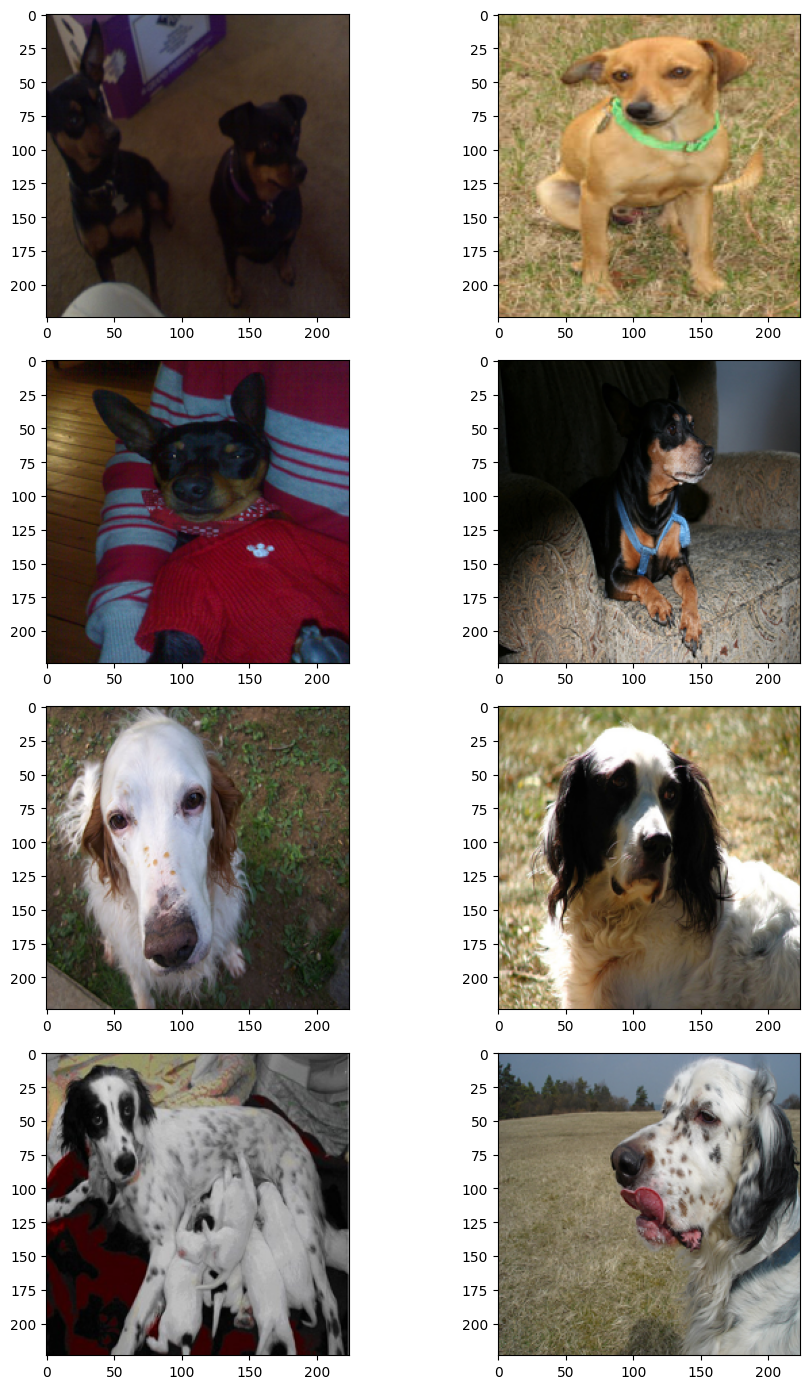

In [38]:
fig, axes = plt.subplots(4, 2, figsize=(10, 14))
image_index = 0
rama =[]
for row in range(4):
    for col in range(2):
        a = reshaped_images[image_index]
        img_array_transposed = np.transpose(a, (1, 2, 0))
        rama.append(img_array_transposed)
        axes[row, col].imshow(img_array_transposed)

        print(f"Image {image_index+1}: Original shape: {a.shape}, Transposed shape: {img_array_transposed.shape}")

        image_index += 1


plt.tight_layout()
plt.show()



Ques 4 b)Convert to Black&White

Original shape: (224, 224, 3), Grayscale shape: (224, 224)
Original shape: (224, 224, 3), Grayscale shape: (224, 224)
Original shape: (224, 224, 3), Grayscale shape: (224, 224)
Original shape: (224, 224, 3), Grayscale shape: (224, 224)
Original shape: (224, 224, 3), Grayscale shape: (224, 224)
Original shape: (224, 224, 3), Grayscale shape: (224, 224)
Original shape: (224, 224, 3), Grayscale shape: (224, 224)
Original shape: (224, 224, 3), Grayscale shape: (224, 224)


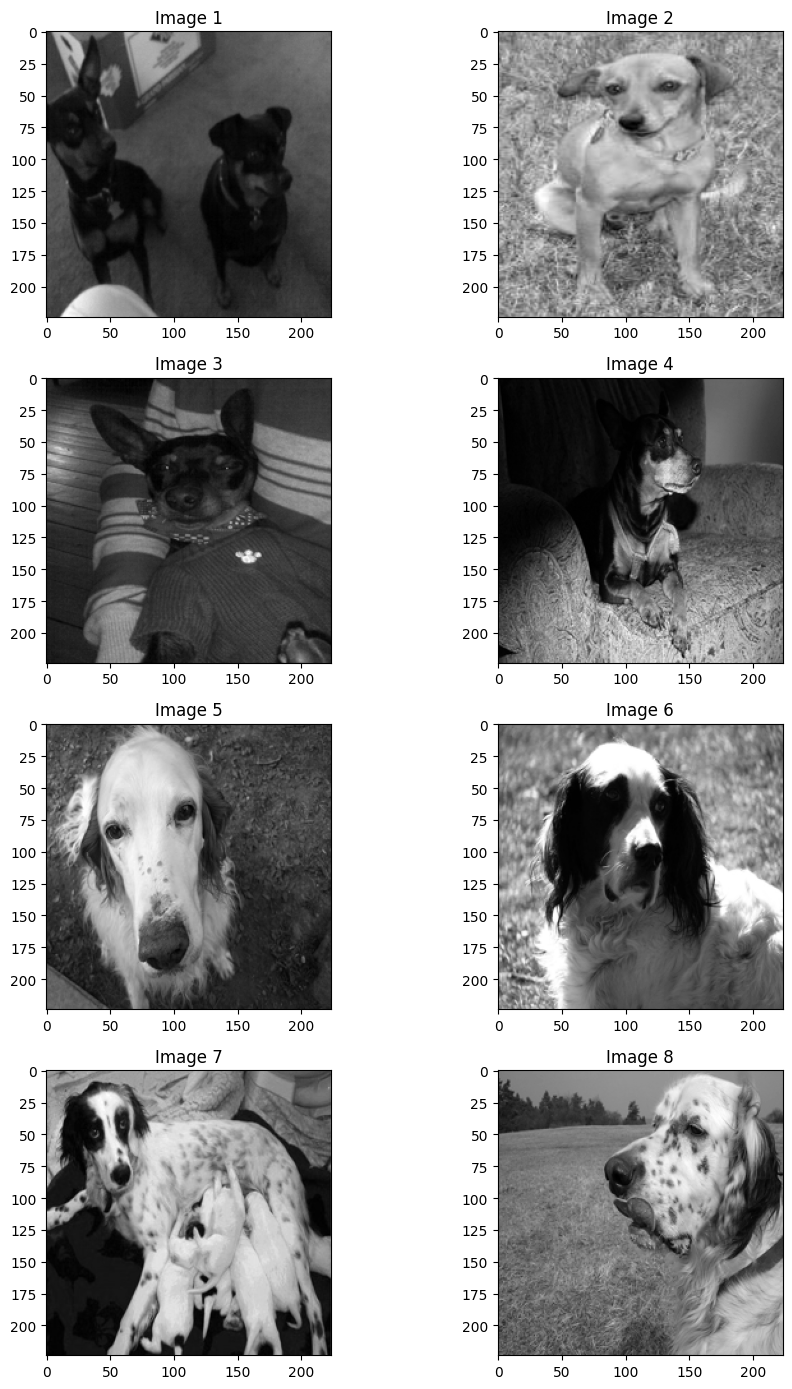

In [39]:
fig, axes = plt.subplots(4, 2, figsize=(10, 14))
for i in range(len(rama)):
    grayscale_image = np.mean(rama[i], axis=2)
    ax = axes[i // 2, i % 2]
    ax.imshow(grayscale_image, cmap='gray')
    ax.set_title(f"Image {i+1}")
    print(f"Original shape: {rama[i].shape}, Grayscale shape: {grayscale_image.shape}")


plt.tight_layout()
plt.show()




**Ques** 4 c) Plot histogram of the image (Color & BW)

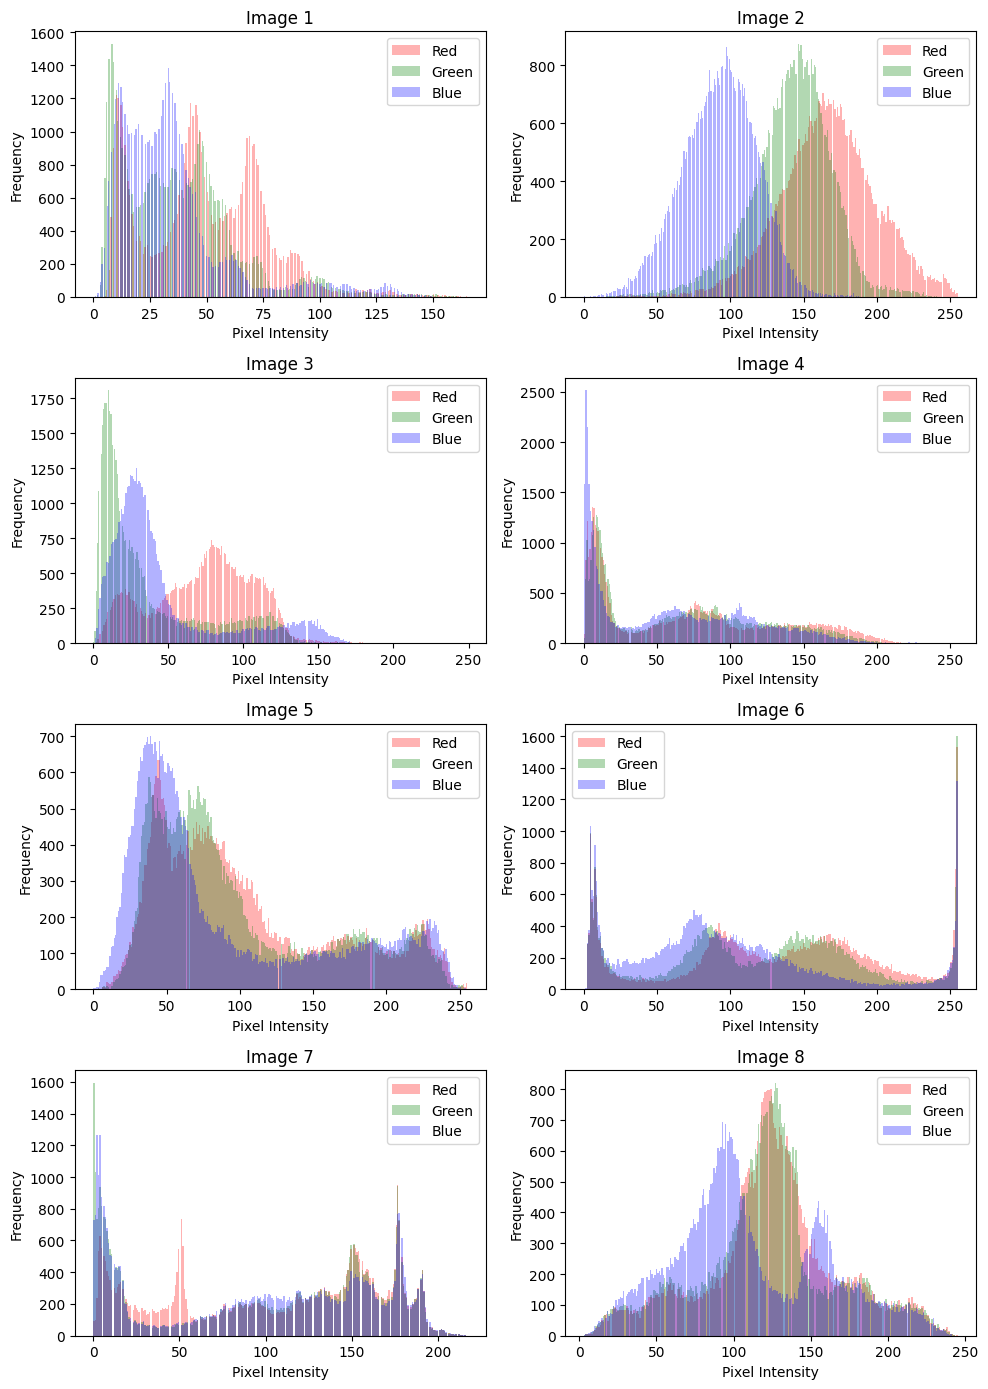

In [40]:
fig, axes = plt.subplots(4, 2, figsize=(10, 14))
axes = axes.flatten()
for idx in range(len(rama)):
    image = rama[idx]

    red_channel = image[:, :, 0].flatten()
    green_channel = image[:, :, 1].flatten()
    blue_channel = image[:, :, 2].flatten()

    ax = axes[idx]
    ax.hist(red_channel, bins=256, color='red', alpha=0.3, label='Red')
    ax.hist(green_channel, bins=256, color='green', alpha=0.3, label='Green')
    ax.hist(blue_channel, bins=256, color='blue', alpha=0.3, label='Blue')


    ax.set_title(f'Image {idx+1}')
    ax.set_xlabel('Pixel Intensity')
    ax.set_ylabel('Frequency')
    ax.legend()

plt.tight_layout()
plt.show()



```
# This is formatted as code
```

Ques 4 c) Histogram for greyscale images

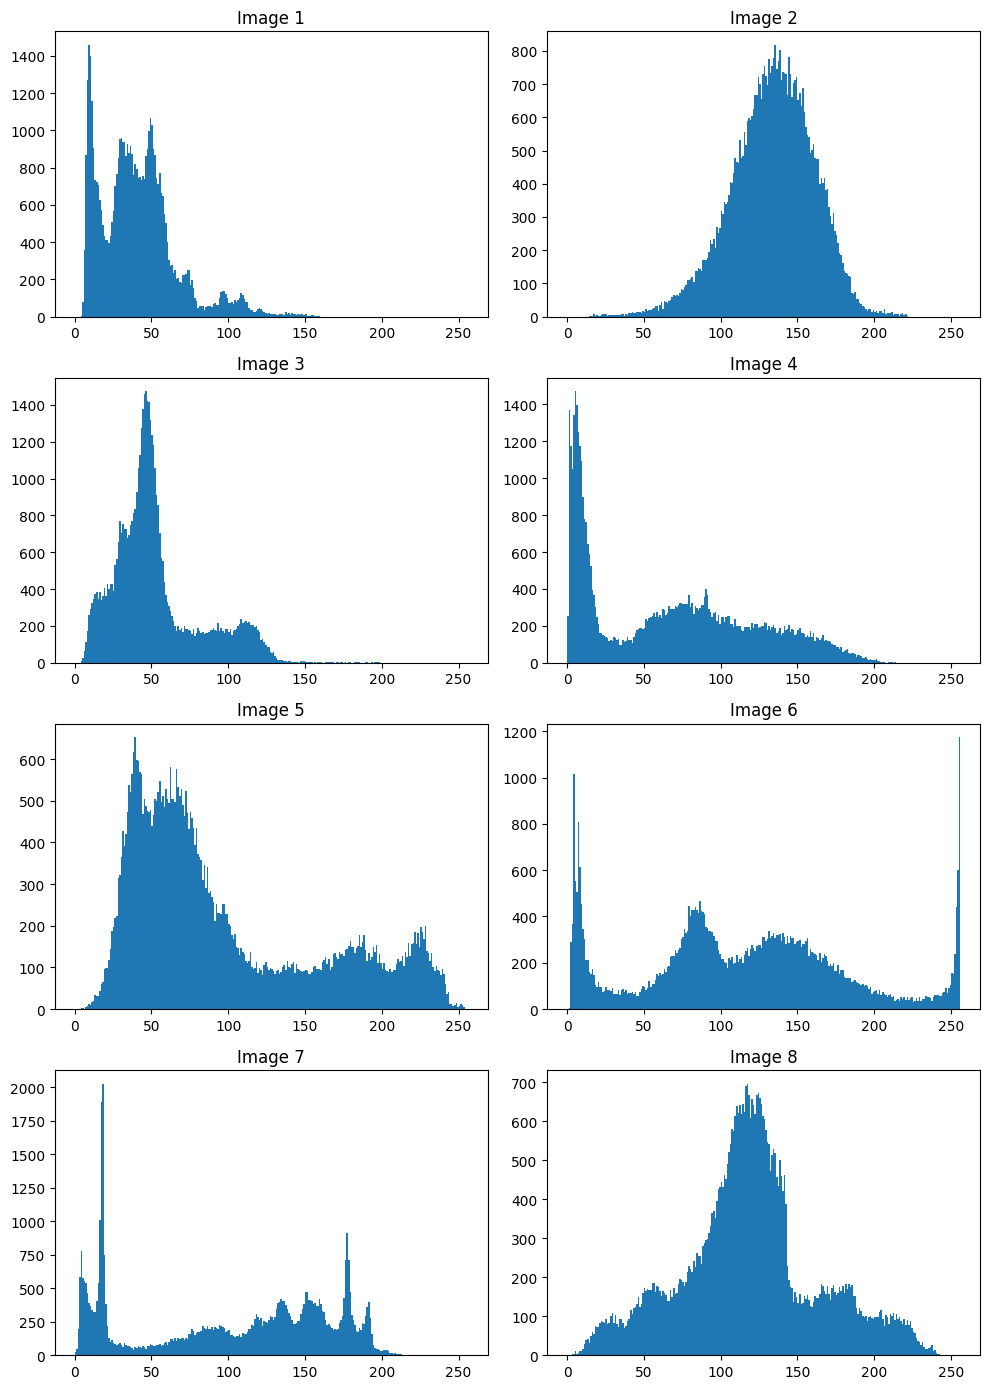

In [41]:
fig, axes = plt.subplots(4, 2, figsize=(10, 14))
for i in range(len(rama)):
    grayscale_image = np.mean(rama[i], axis=2)
    ax = axes[i // 2, i % 2]
    ax.hist(grayscale_image.ravel(), 256, [0, 256])
    ax.set_title(f"Image {i+1}")

plt.tight_layout()
plt.show()

**Ques** 4 d)Calculate CenterOfMass for all images.

In [42]:
#function for calculating center of mass of image
def center_of_mass(image):
    grayscale = image.convert('L')
    img_array = np.array(grayscale)

    y, x = np.indices(img_array.shape)
    total_mass = img_array.sum()
    cx = (x * img_array).sum() / total_mass
    cy = (y * img_array).sum() / total_mass

    return cx, cy



In [43]:
centers_of_mass = []
for path in image_paths:
    image = Image.open(path)
    cx, cy = center_of_mass(image)
    centers_of_mass.append((cx, cy))

for i, com in enumerate(centers_of_mass):
    print(f"Center of Mass for Image {i+1} : {com}")

Center of Mass for Image 1 : (248.29682449231694, 168.20859042772773)
Center of Mass for Image 2 : (88.45683657772813, 124.1716422192515)
Center of Mass for Image 3 : (184.83297380824376, 248.6805971425022)
Center of Mass for Image 4 : (294.0222027133679, 216.79513158991818)
Center of Mass for Image 5 : (213.7178142057114, 169.06086384092131)
Center of Mass for Image 6 : (249.0623204281386, 177.98150564059765)
Center of Mass for Image 7 : (214.95101471974226, 134.62439238706008)
Center of Mass for Image 8 : (260.7584074221321, 183.98840362242078)
Center of Mass for Image 9 : (246.36191947954225, 177.38914447812914)
Center of Mass for Image 10 : (243.96013210598102, 172.89353228845874)
Center of Mass for Image 11 : (252.53184074267637, 197.1119537960504)
Center of Mass for Image 12 : (258.54643727436047, 288.28284030761466)
Center of Mass for Image 13 : (239.41532208632051, 152.48855177417073)
Center of Mass for Image 14 : (276.6280255799694, 172.9901115020123)
Center of Mass for Image 

Ques 4: Audio Data

In [44]:
name_codes

['n02107312', 'n02100735', 'n01582220', 'n10565667']

In [48]:
path= '/content/drive/MyDrive/Colab Notebooks/Dataset/MLA1/MLA1_DATA/ImageAudio/'
audio_path=[]
for o in name_codes:
  audio_path.append(path + o+ ".wav")
audio_path

['/content/drive/MyDrive/Colab Notebooks/Dataset/MLA1/MLA1_DATA/ImageAudio/n02107312.wav',
 '/content/drive/MyDrive/Colab Notebooks/Dataset/MLA1/MLA1_DATA/ImageAudio/n02100735.wav',
 '/content/drive/MyDrive/Colab Notebooks/Dataset/MLA1/MLA1_DATA/ImageAudio/n01582220.wav',
 '/content/drive/MyDrive/Colab Notebooks/Dataset/MLA1/MLA1_DATA/ImageAudio/n10565667.wav']

**Ques** 4 a)Resample audio to 16000 Hz

In [49]:
import scipy.io.wavfile as wavfile
from scipy.signal import resample

In [50]:
target_sr= 16000
for path in audio_path:
    original_sr, audio_data = wavfile.read(path)
    new_length = int(len(audio_data) * (target_sr / original_sr))
    resampled_audio = resample(audio_data, new_length)
    print(f"Resampled from audio {original_sr} Hz to {target_sr} Hz.")

<ipython-input-50-048710b2513c>:3: WavFileWarning: Chunk (non-data) not understood, skipping it.
  original_sr, audio_data = wavfile.read(path)


Resampled from audio 16000 Hz to 16000 Hz.
Resampled from audio 16000 Hz to 16000 Hz.
Resampled from audio 16000 Hz to 16000 Hz.
Resampled from audio 16000 Hz to 16000 Hz.


Ques 4 b)Convert to MelSpectrogram

In [51]:
from scipy.io import wavfile
from scipy.signal import spectrogram
from scipy.fft import fft, fftfreq

<ipython-input-52-6d16997f2b9d>:2: WavFileWarning: Chunk (non-data) not understood, skipping it.
  sample_rate, audio_data = wavfile.read(file_path)


16000


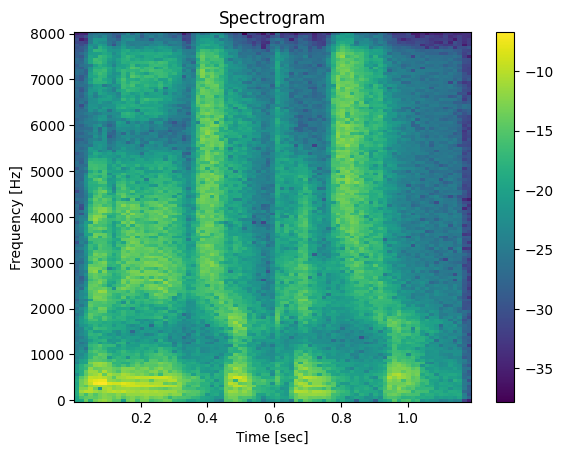

16000


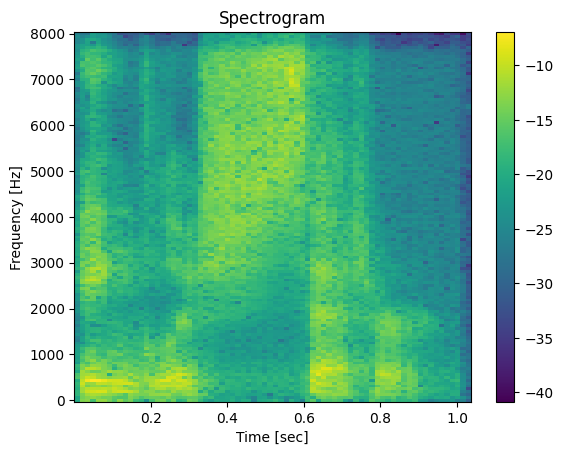

16000


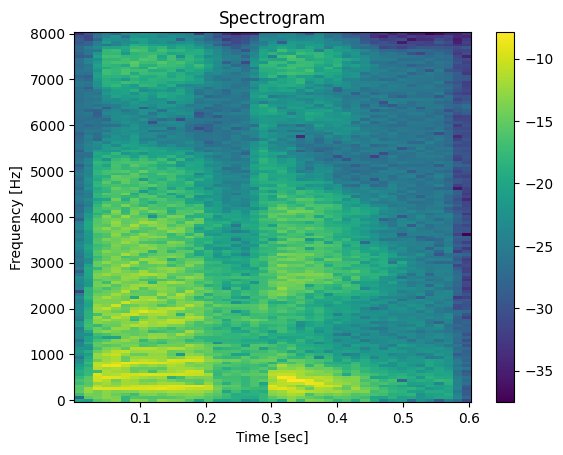

16000


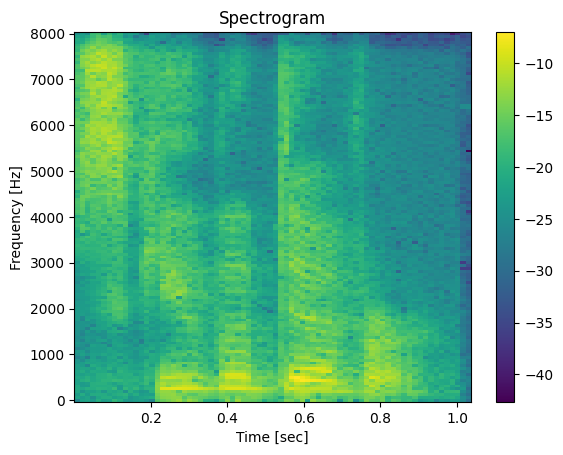

In [52]:
for file_path in audio_path:
  sample_rate, audio_data = wavfile.read(file_path)
  print(sample_rate)
  frequencies, times, spectrogram_data = spectrogram(audio_data, fs=sample_rate)
  plt.pcolormesh(times, frequencies, np.log(spectrogram_data), cmap='viridis')
  plt.ylabel('Frequency [Hz]')
  plt.xlabel('Time [sec]')
  plt.title('Spectrogram')
  plt.colorbar()
  plt.show()

Ques 4 c) Ploting time-domain & frequency-domain signal

<ipython-input-53-d8e4592f97e9>:2: WavFileWarning: Chunk (non-data) not understood, skipping it.
  sample_rate, audio_data = wavfile.read(i)


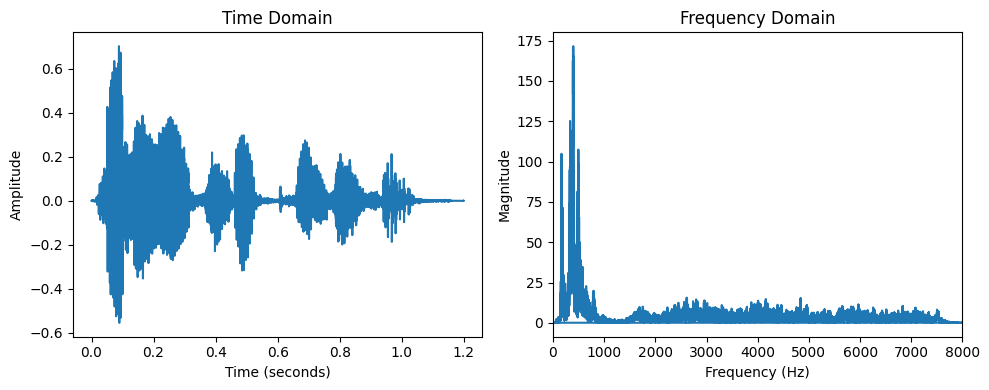

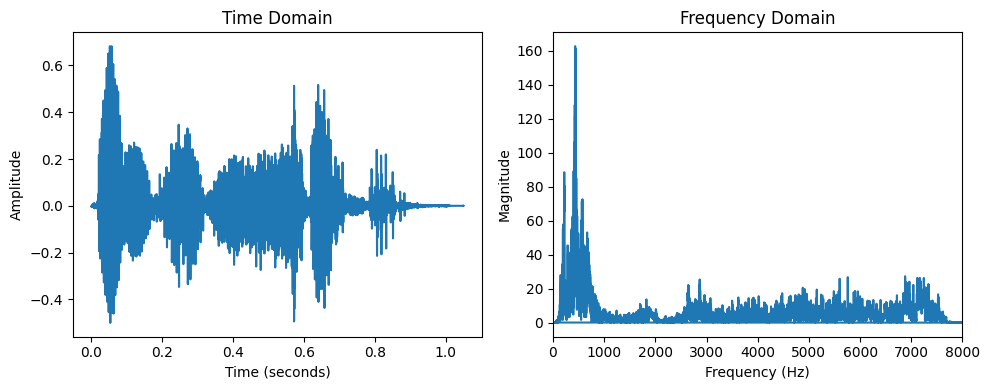

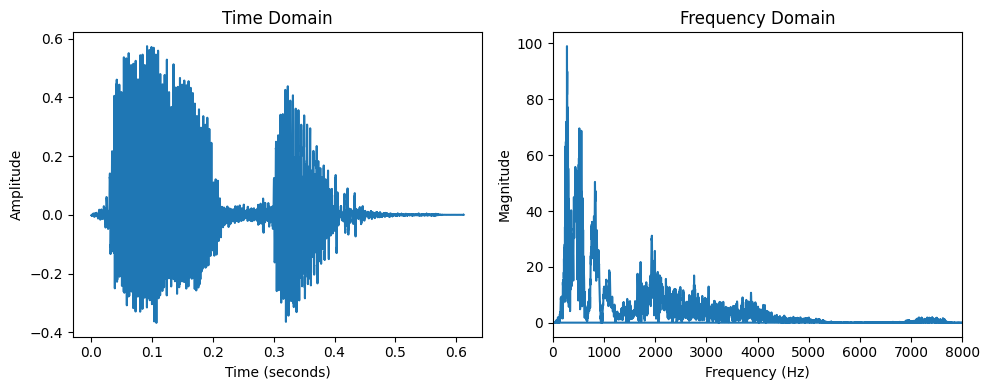

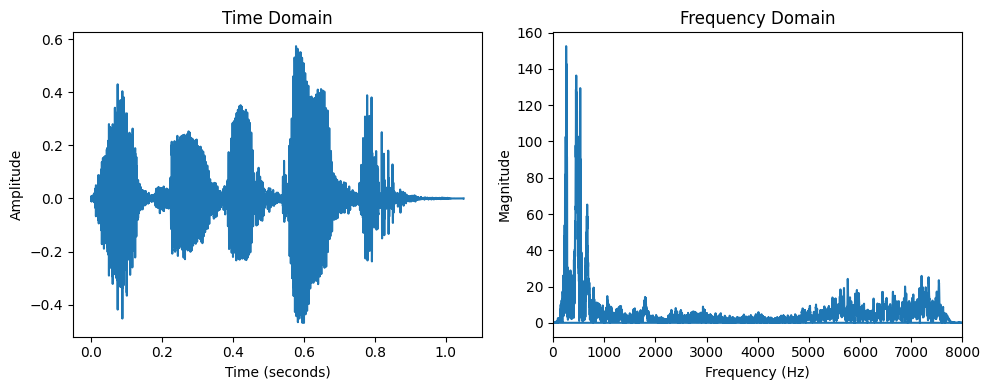

In [53]:
for i in audio_path:
  sample_rate, audio_data = wavfile.read(i)

  plt.figure(figsize=(10, 4))

  plt.subplot(1, 2, 1)
  time_axis = np.arange(len(audio_data)) / sample_rate
  plt.plot(time_axis, audio_data)
  plt.title('Time Domain')
  plt.xlabel('Time (seconds)')
  plt.ylabel('Amplitude')

  plt.subplot(1, 2, 2)
  fft_result = fft(audio_data)
  magnitude_spectrum = np.abs(fft_result)
  frequency_axis = fftfreq(len(audio_data), 1.0 / sample_rate)
  plt.plot(frequency_axis, magnitude_spectrum)
  plt.title('Frequency Domain')
  plt.xlabel('Frequency (Hz)')
  plt.ylabel('Magnitude')
  plt.xlim(0, sample_rate / 2)

  plt.tight_layout()
  plt.show()

**Ques** 4 d) Calculate ZeroCrossingRate for all time-domain signals.

In [54]:
audio_path

['/content/drive/MyDrive/Colab Notebooks/Dataset/MLA1/MLA1_DATA/ImageAudio/n02107312.wav',
 '/content/drive/MyDrive/Colab Notebooks/Dataset/MLA1/MLA1_DATA/ImageAudio/n02100735.wav',
 '/content/drive/MyDrive/Colab Notebooks/Dataset/MLA1/MLA1_DATA/ImageAudio/n01582220.wav',
 '/content/drive/MyDrive/Colab Notebooks/Dataset/MLA1/MLA1_DATA/ImageAudio/n10565667.wav']

In [55]:
def zero_crossing_rate(audio_data):
  zero_crossings = np.where(np.diff(np.sign(audio_data)))[0]
  return len(zero_crossings) / len(audio_data)


In [56]:
# Calculate Zero-Crossing Rate for each audio file
i=1;
for file_path in audio_path:
  sample_rate, audio_data = wavfile.read(file_path)
  zcr = zero_crossing_rate(audio_data)
  print(f"Zero-crossing rate for audio file {i} {zcr}")
  i+=1

Zero-crossing rate for audio file 1 0.19765625
Zero-crossing rate for audio file 2 0.2619047619047619
Zero-crossing rate for audio file 3 0.11061224489795918
Zero-crossing rate for audio file 4 0.22095238095238096


<ipython-input-56-b2437314f079>:4: WavFileWarning: Chunk (non-data) not understood, skipping it.
  sample_rate, audio_data = wavfile.read(file_path)


Ques 5) Calculate and plot PowerSpectralDensity (PSD) of EEG signals.

In [57]:
sample_csv

['MindBigData_Imagenet_Insight_n02107312_3248_1_277.csv',
 'MindBigData_Imagenet_Insight_n02100735_4949_1_1411.csv',
 'MindBigData_Imagenet_Insight_n01582220_80_1_1061.csv',
 'MindBigData_Imagenet_Insight_n10565667_8400_1_378.csv']

MindBigData_Imagenet_Insight_n02107312_3248_1_277.csv


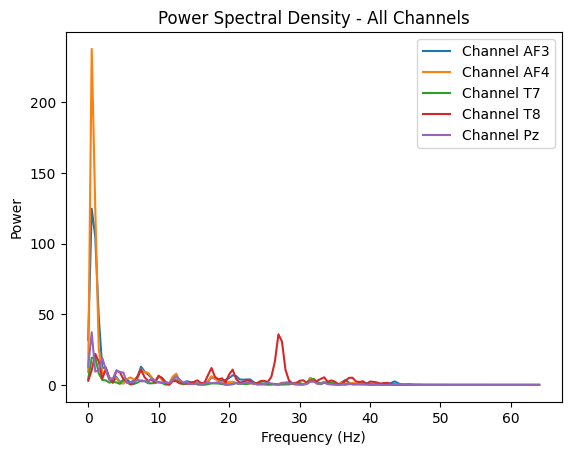

MindBigData_Imagenet_Insight_n02100735_4949_1_1411.csv


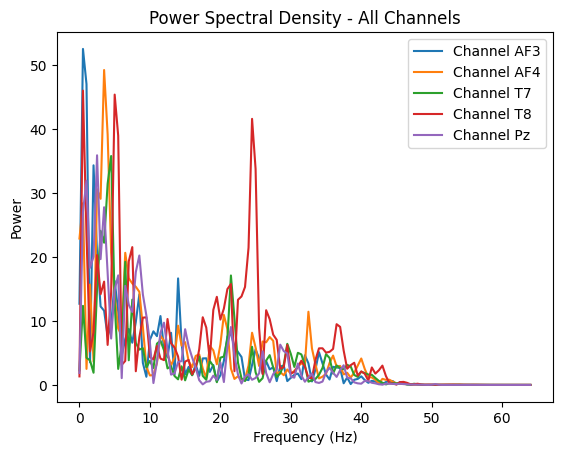

MindBigData_Imagenet_Insight_n01582220_80_1_1061.csv


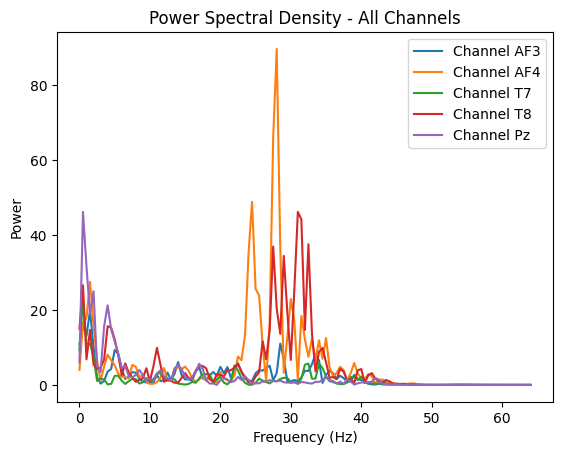

MindBigData_Imagenet_Insight_n10565667_8400_1_378.csv


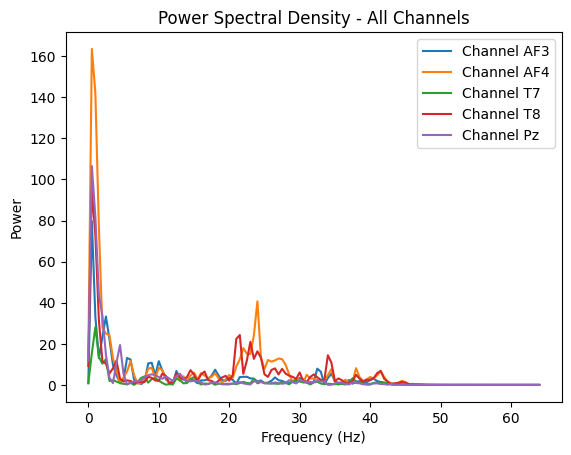

In [59]:
from scipy.signal import welch
for i in sample_csv:
  f_path = '/content/drive/MyDrive/Colab Notebooks/Dataset/MLA1/MLA1_DATA/CSV/'+i
  df = pd.read_csv(f_path, header=None, index_col=0).T
  plt.figure()

  for channel in df.columns:
      signal = df[channel].values
      freqs, psd = welch(signal, fs=128)

      plt.plot(freqs, psd, label=f'Channel {channel}')

  plt.title('Power Spectral Density - All Channels')
  plt.xlabel('Frequency (Hz)')
  plt.ylabel('Power')
  plt.legend()
  print(i)
  plt.show()

**Intermediate**

Ques 2) Perform exploratory data analysis (EDA) on Image

In [60]:
name_codes

['n02107312', 'n02100735', 'n01582220', 'n10565667']

In [61]:
path = '/content/drive/MyDrive/Colab Notebooks/Dataset/MLA1/MLA1_DATA/ImageAudio/'
for i in name_codes:
    all_files = os.listdir(path+i)
    print("Size of Image folder",i,"is",os.path.getsize(path+i))
    #print(os.path.getsize(path+i))

Size of Image folder n02107312 is 4096
Size of Image folder n02100735 is 4096
Size of Image folder n01582220 is 4096
Size of Image folder n10565667 is 4096


EDA on Audio data

In [62]:
import os

def get_folder_size_kb(folder_path):
    total_size = 0
    for dirpath, dirnames, filenames in os.walk(folder_path):
        for filename in filenames:
            file_path = os.path.join(dirpath, filename)
            total_size += os.path.getsize(file_path)

    # Convert bytes to kilobytes (1 KB = 1024 bytes)
    size_in_kb = total_size /(1024*1024)
    return size_in_kb




In [63]:
folder_path ='/content/drive/MyDrive/Colab Notebooks/Dataset/MLA1/MLA1_DATA/ImageAudio/'
for i in name_codes:
  folder_size_kb = get_folder_size_kb(folder_path+i)
  print(f"Folder size: {folder_size_kb:.2f} MB")

Folder size: 1.71 MB
Folder size: 1.69 MB
Folder size: 2.86 MB
Folder size: 1.82 MB


Visualisation of images

In [64]:
c=0;
for i in image_paths:
  c+=1
  image = Image.open(i)
  image_array = np.array(image)
  plt.title(("original shape " ,image_array.shape))
  plt.imshow(image_array)
  plt.show()
  if c==8:
    break


Output hidden; open in https://colab.research.google.com to view.

Statistical Analysis on images

In [65]:
def image_statistics(image):
    image = Image.open(image)
    grayscale = image.convert('L')
    img_array = np.array(grayscale)

    mean = np.mean(img_array)
    std_dev = np.std(img_array)

    return mean, std_dev




Mean Pixel Intensity: 40.825472
Standard Deviation of Pixel Intensity: 25.719203382762128


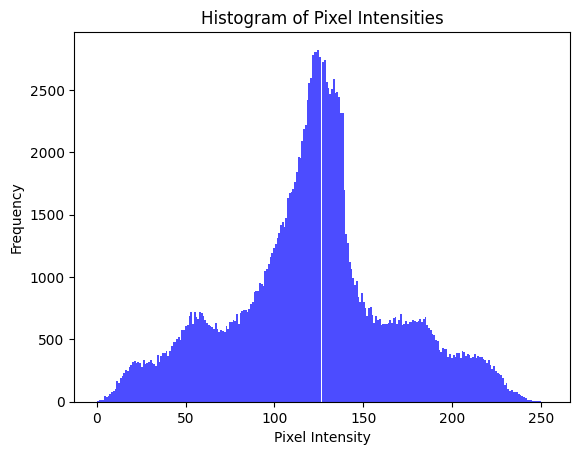

Mean Pixel Intensity: 143.3254593175853
Standard Deviation of Pixel Intensity: 28.572057135180327


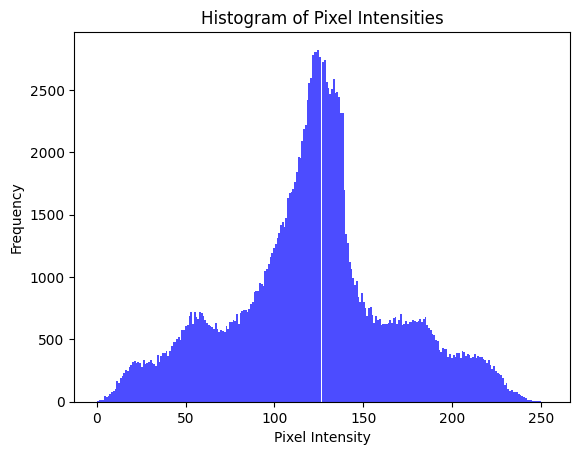

Mean Pixel Intensity: 49.54189866666667
Standard Deviation of Pixel Intensity: 28.95720961180016


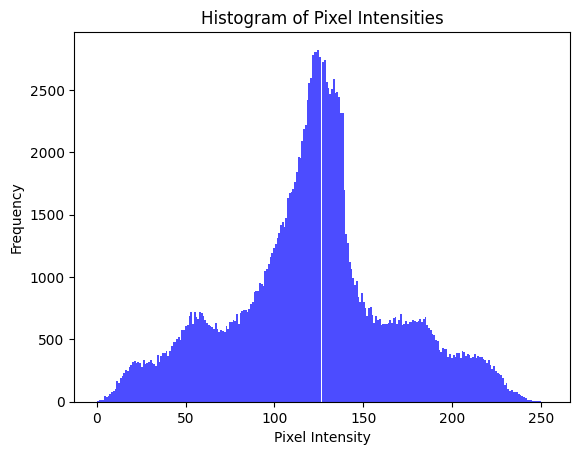

Mean Pixel Intensity: 68.48268882175226
Standard Deviation of Pixel Intensity: 56.70607065886175


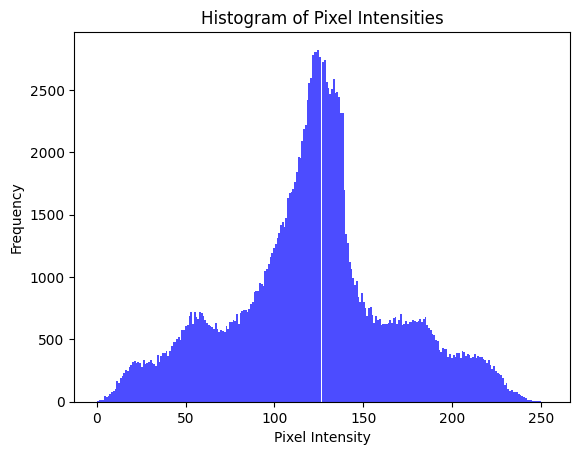

Mean Pixel Intensity: 99.20592
Standard Deviation of Pixel Intensity: 60.62996959387001


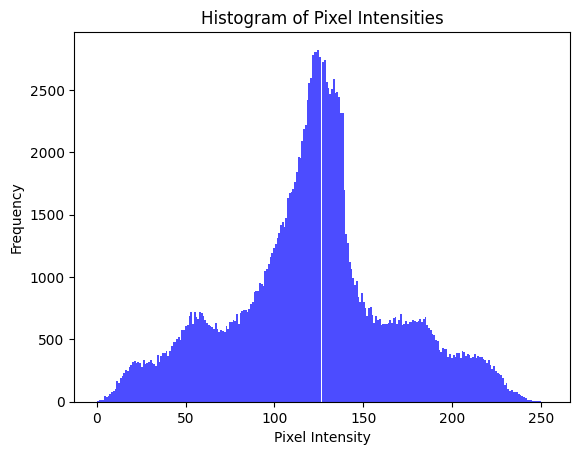

Mean Pixel Intensity: 119.73293866666667
Standard Deviation of Pixel Intensity: 69.55354607478739


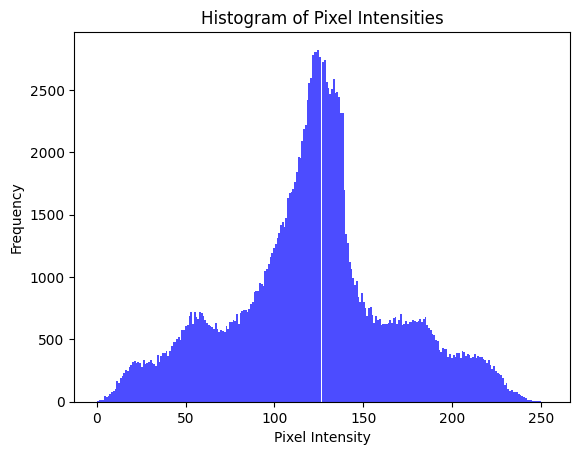

Mean Pixel Intensity: 101.21645547945205
Standard Deviation of Pixel Intensity: 64.39443559331488


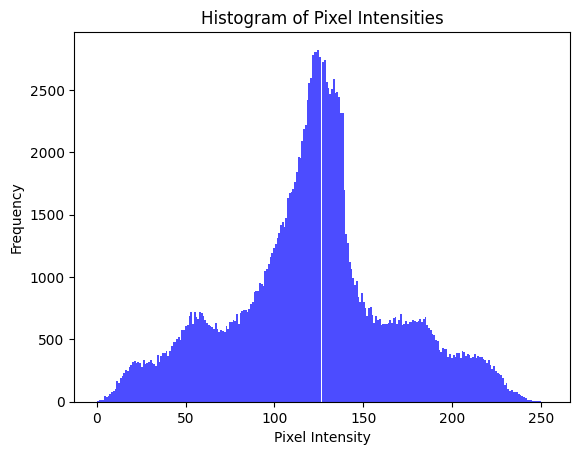

Mean Pixel Intensity: 121.24429866666667
Standard Deviation of Pixel Intensity: 45.83307415133164


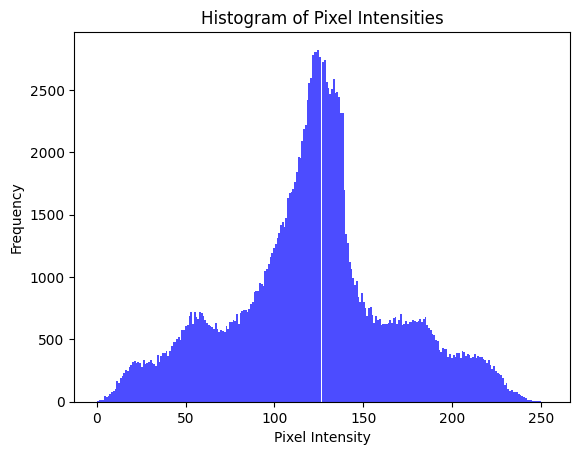

Mean Pixel Intensity: 104.26104
Standard Deviation of Pixel Intensity: 43.20862694090614


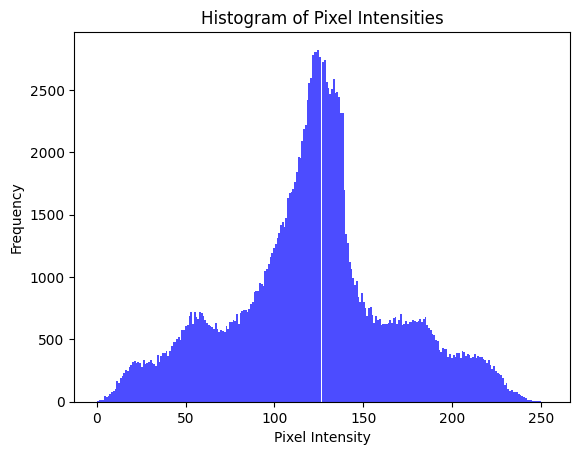

Mean Pixel Intensity: 122.07049710982659
Standard Deviation of Pixel Intensity: 33.6916260515229


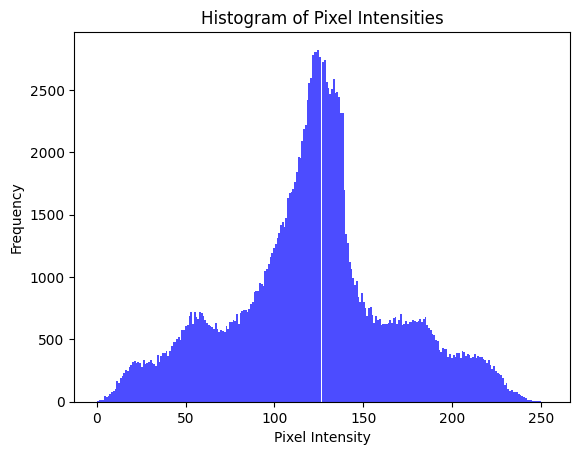

Mean Pixel Intensity: 133.5881144278607
Standard Deviation of Pixel Intensity: 49.43054916821664


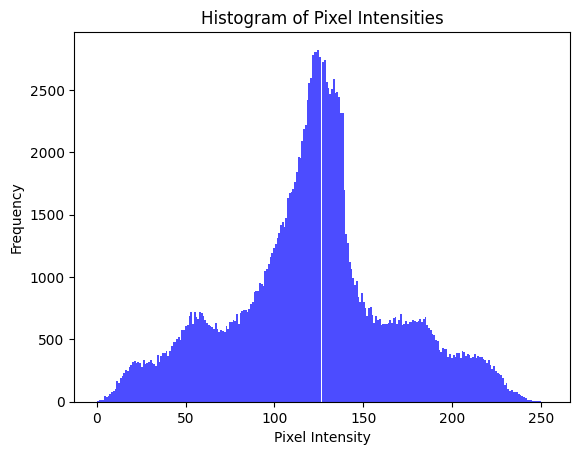

Mean Pixel Intensity: 104.44756
Standard Deviation of Pixel Intensity: 78.12935516210537


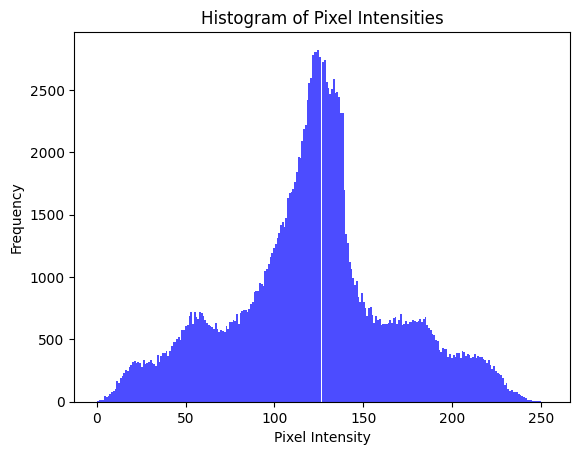

Mean Pixel Intensity: 93.37485882352941
Standard Deviation of Pixel Intensity: 29.700533541118887


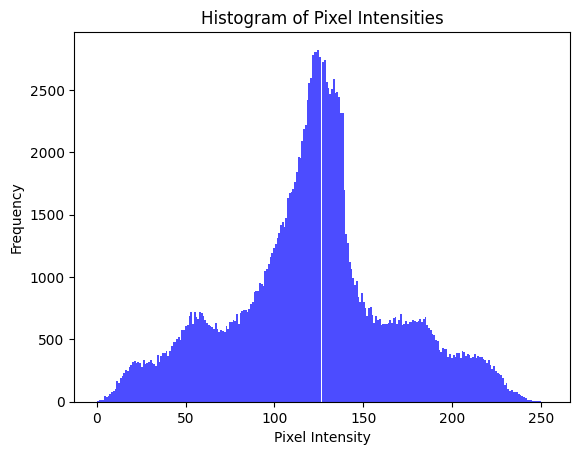

Mean Pixel Intensity: 81.71810666666667
Standard Deviation of Pixel Intensity: 53.171029882966245


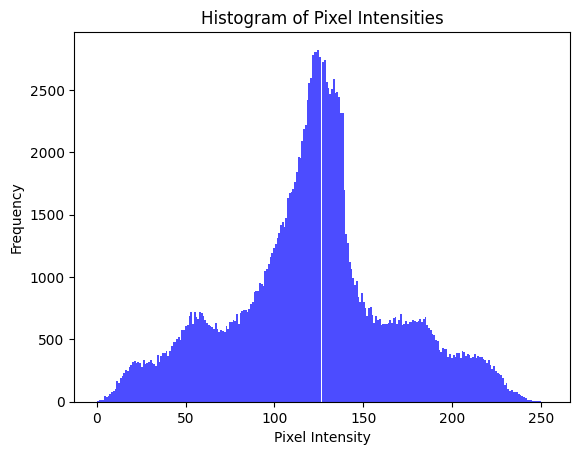

Mean Pixel Intensity: 123.22744
Standard Deviation of Pixel Intensity: 29.207644462475916


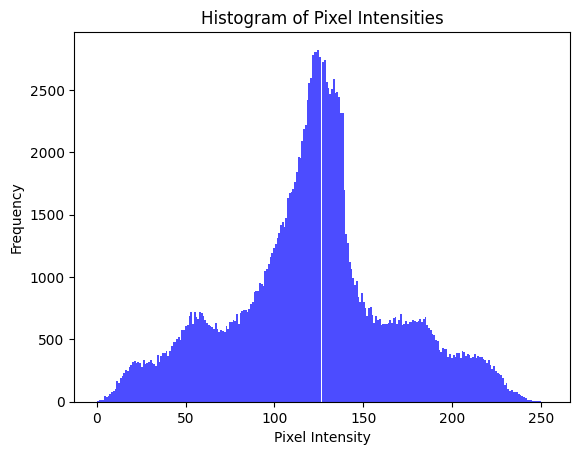

Mean Pixel Intensity: 98.805872
Standard Deviation of Pixel Intensity: 33.212119308865


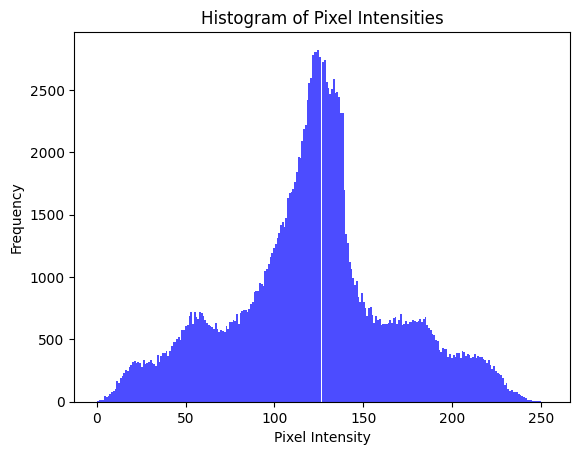

In [66]:
for i in image_paths:
  mean, std_dev = image_statistics(i)
  print(f"Mean Pixel Intensity: {mean}")
  print(f"Standard Deviation of Pixel Intensity: {std_dev}")

  # Plot the histogram of pixel intensities
  plt.hist(np.array(image.convert('L')).flatten(), bins=256, color='blue', alpha=0.7)
  plt.title('Histogram of Pixel Intensities')
  plt.xlabel('Pixel Intensity')
  plt.ylabel('Frequency')
  plt.show()

Outlier detection on image data

In [67]:
def detect_outliers(statistics, threshold=3):
    mean = np.mean(statistics)
    std_dev = np.std(statistics)
    z_score = (statistics - mean) / std_dev
    if np.abs(z_score) > threshold:
        return True
    return False

is_mean_outlier = detect_outliers(mean)
is_std_dev_outlier = detect_outliers(std_dev)

print(f"outlier {'Yes' if is_mean_outlier else 'No'}")


outlier No


<ipython-input-67-35282419293f>:4: RuntimeWarning: invalid value encountered in scalar divide
  z_score = (statistics - mean) / std_dev
